In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, auc)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Matplotlib is building the font cache; this may take a moment.


ModuleNotFoundError: No module named 'xgboost'

In [2]:
df = pd.read_csv(r"D:\ML_Project\ai4i2020.csv")

print("Shape:", df.shape)
df.head()

Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
print(df.columns)
print(df.dtypes)
df.describe()

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [4]:
print(df.isnull().sum())

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [5]:
df_clean = df.copy()

df_clean.drop(columns=['UDI', 'Product ID'], inplace=True)

le = LabelEncoder()
df_clean['Type'] = le.fit_transform(df_clean['Type'])

df_clean.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
def get_failure_type(row):
    if row['TWF']: return 'TWF'
    elif row['HDF']: return 'HDF'
    elif row['PWF']: return 'PWF'
    elif row['OSF']: return 'OSF'
    elif row['RNF']: return 'RNF'
    else: return 'No Failure'

df_clean['Failure_Type'] = df.apply(get_failure_type, axis=1)

df_clean['Failure_Type'].value_counts()

Failure_Type
No Failure    9652
HDF            115
PWF             91
OSF             78
TWF             46
RNF             18
Name: count, dtype: int64

In [10]:
import os

os.makedirs("plots", exist_ok=True)
print("Plots folder created")

Plots folder created


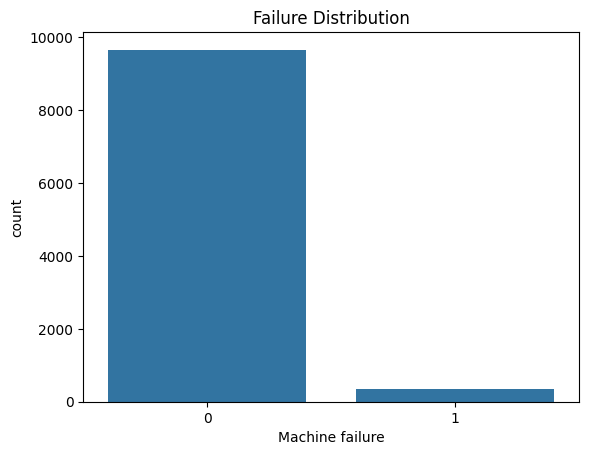

In [11]:
plt.figure()
sns.countplot(x='Machine failure', data=df_clean)
plt.title("Failure Distribution")

plt.savefig("plots/failure_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

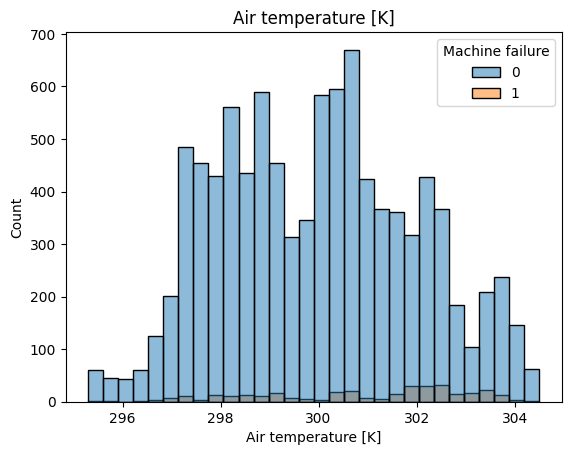

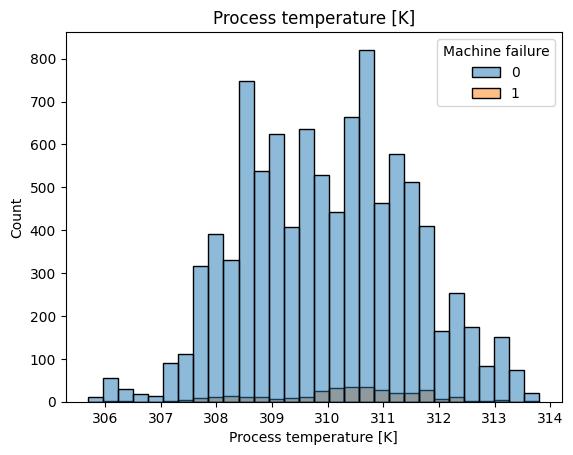

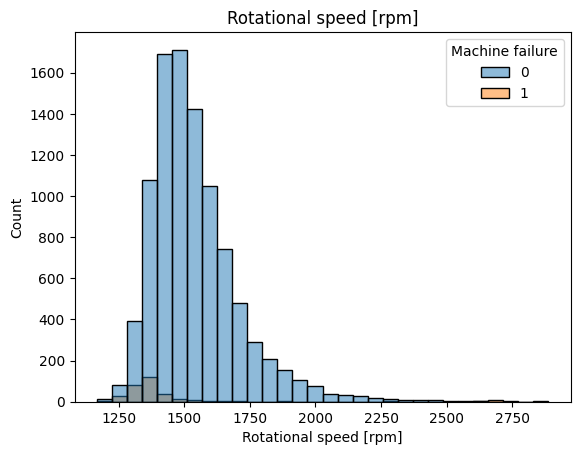

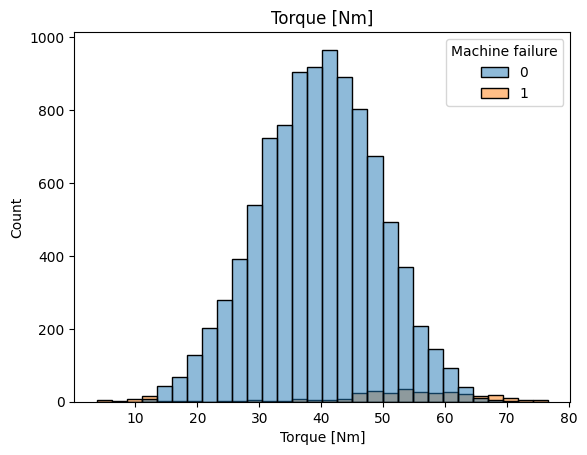

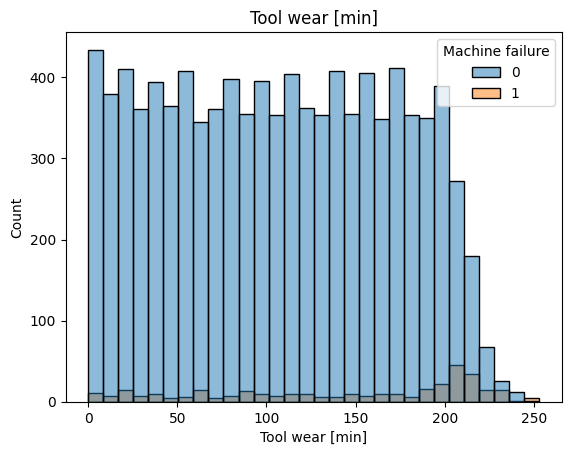

In [12]:
features = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

for feature in features:
    plt.figure()
    sns.histplot(data=df_clean, x=feature, hue='Machine failure', bins=30)
    plt.title(feature)

    plt.savefig(f"plots/{feature}_distribution.png", dpi=300, bbox_inches='tight')
    plt.show()

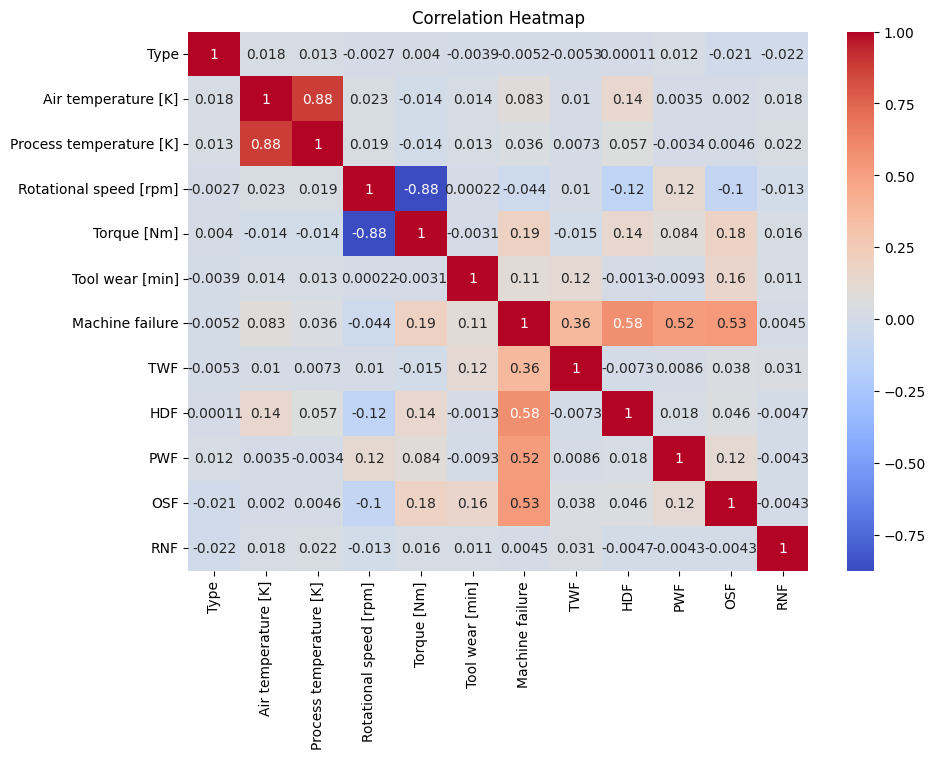

In [13]:
numeric_df = df_clean.select_dtypes(include=[np.number])

plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")

plt.savefig("plots/correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [14]:
features = ['Type', 'Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

X = df_clean[features]
y = df_clean['Machine failure']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [17]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print("Before:", np.bincount(y_train))
print("After:", np.bincount(y_train_sm))

Before: [7729  271]
After: [7729 7729]


In [18]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True)
}

In [20]:
results = {}

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:,1]
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    }

results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1 Score,AUC
Logistic Regression,0.8230,0.142500,0.838235,0.243590,0.907358
Random Forest,0.9705,0.547368,0.764706,0.638037,0.968910
XGBoost,0.9765,0.615385,0.823529,0.704403,0.971524
Decision Tree,0.9575,0.426087,0.720588,0.535519,0.843213
KNN,0.9320,0.302326,0.764706,0.433333,0.896602
SVM,0.9200,0.285047,0.897059,0.432624,0.964164


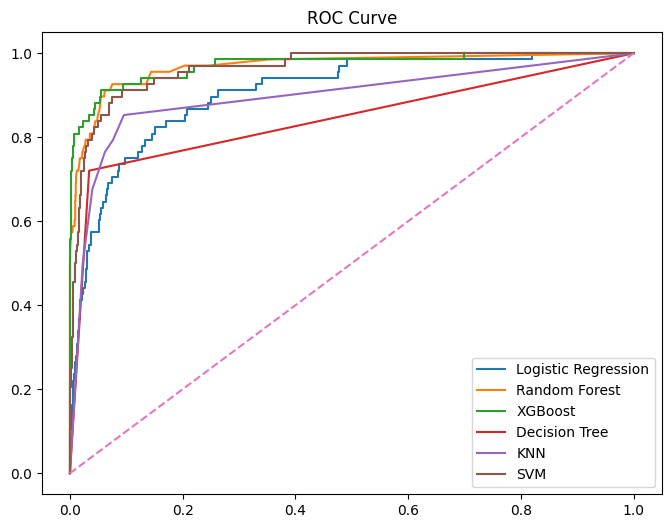

In [22]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test_sc)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")

plt.savefig("plots/roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()

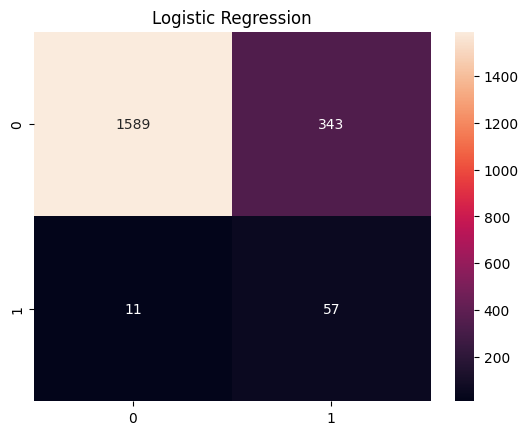

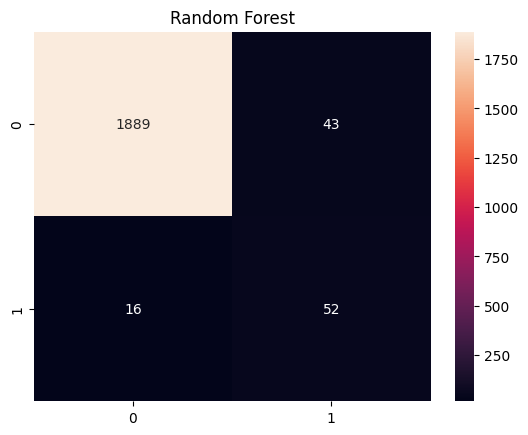

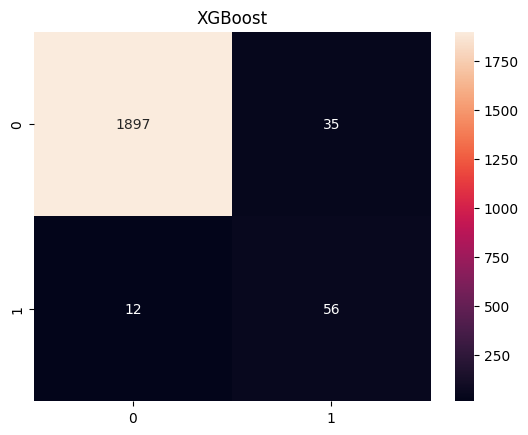

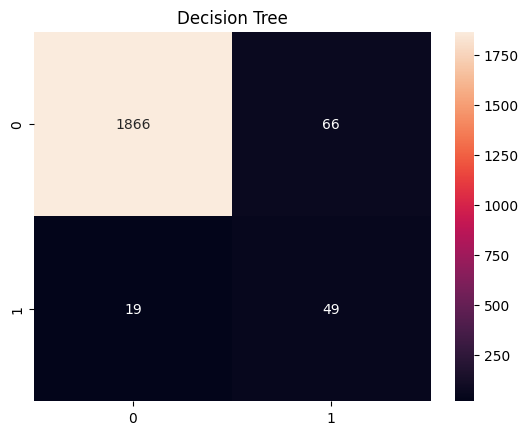

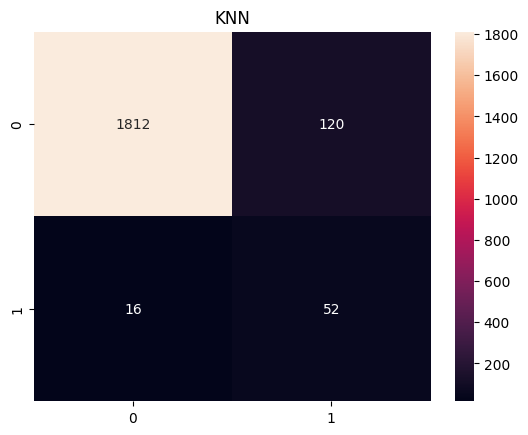

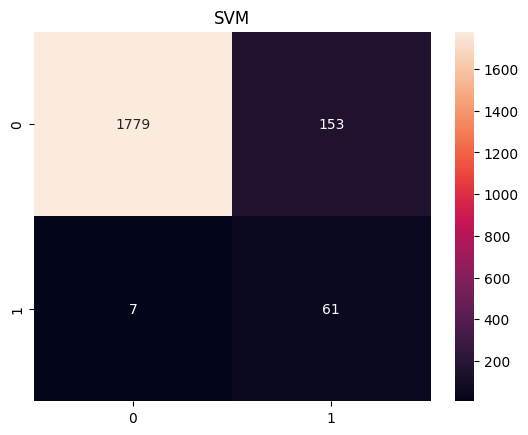

In [23]:
for name, model in models.items():
    y_pred = model.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(name)

    plt.savefig(f"plots/confusion_{name}.png", dpi=300, bbox_inches='tight')
    plt.show()

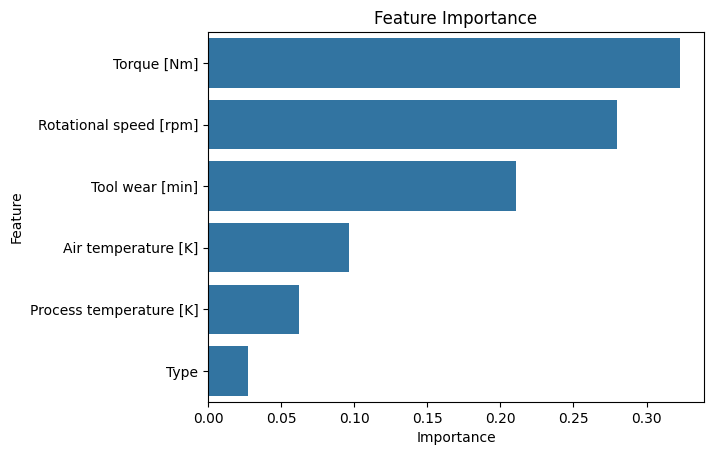

In [24]:
rf = models["Random Forest"]
importances = rf.feature_importances_

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure()
sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Feature Importance")

plt.savefig("plots/feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

In [25]:
print("Final Results:\n")
print(results_df)

best_model = results_df['F1 Score'].idxmax()

print("\nBest Model:", best_model)

Final Results:

                     Accuracy  Precision    Recall  F1 Score       AUC
Logistic Regression    0.8230   0.142500  0.838235  0.243590  0.907358
Random Forest          0.9705   0.547368  0.764706  0.638037  0.968910
XGBoost                0.9765   0.615385  0.823529  0.704403  0.971524
Decision Tree          0.9575   0.426087  0.720588  0.535519  0.843213
KNN                    0.9320   0.302326  0.764706  0.433333  0.896602
SVM                    0.9200   0.285047  0.897059  0.432624  0.964164

Best Model: XGBoost
